# Downloading And Plotting Current RAWS Station Observed Energy Release Components

In this example we will use WxData to download the latest RAWS Fuels Observations.

We will then use Matplotlib, Shapeography and Cartopy to plot the latest Energy Release Component observations on a map across California and Nevada.

**If you are getting SSL Certificate Errors when trying to download data, you may be using a proxy server connection**

We will not be doing any proxy connection examples. 

How to set up a proxy:

proxies (dict or None) - Default=None. If the user is using proxy server(s), the user must change the following:

       proxies=None ---> proxies={
                               'http':'http://your-proxy-address:port',
                               'https':'http://your-proxy-address:port'
                               }

For more information on configuring proxies: https://requests.readthedocs.io/en/latest/user/advanced/#proxies

## Imports

In [1]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import pandas as pd

from wxdata import get_current_all_raws_station_fuels_observations
from shapeography import(
    client,
    unzip,
    geometry
)

## Retrieving Our Fuels Data

We will need to retrieve our data using `get_current_all_raws_station_fuels_observations()` 

Here is the documentation for `get_current_all_raws_station_fuels_observations()`

***def get_current_all_raws_station_fuels_observations(state='all', fuel_model='Y', clear_recycle_bin=False, path=f'{folder_modified}/FEMS Data/Current Multi Station/Observations/Fuels', proxies=None, clear_data=True, meta_path=f'{folder_modified}/FEMS Data/Station Meta Data', sheet_name='Sheet1'):***

This function retrieves all current fuels observations for all RAWS Stations of a given state.

Required Arguments: None

Optional Arguments:

1) state (String) - Default='all'. The 2-letter state identifier. Defaults to the entire U.S. 

2) fuel_model (String) - Default = 'Y'. The fuel model being used. 
    Fuel Models List:

    Y - Timber
    X - Brush
    W - Grass/Shrub
    V - Grass
    Z - Slash

3) clear_recycle_bin (Boolean) - Default=False. When set to True, the contents in your recycle/trash bin will be deleted 
    with each run of the program you are calling WxData. This setting is to help preserve memory on the machine. 
    
4) path (String) - Default=f'{folder_modified}/FEMS Data/Current Multi Station/Observations/Fuels'. 
    The directory the data will be saved to.
    
5) proxies (dict or None) - Default=None. If the user is using proxy server(s), the user must change the following:

   proxies=None ---> proxies={
                           'http':'http://your-proxy-address:port',
                           'https':'http://your-proxy-address:port'
                           }

5) clear_data (Boolean) - Default=True. When set to True, the data directory clears out and new data is downloaded.

6) meta_path (String) - Default=f'{folder_modified}/FEMS Data/Station Meta Data'. 
    The path to where the RAWS station meta data excel file will be saved to. 
    
7) sheet_name (String) - The name of the sheet in the excel file to be converted into a pandas.DataFrame.

**Returns**

A Pandas DataFrame of current observed fuels data with lat/lon coordinates for each station merged from the meta-data file.



In [2]:
ca = get_current_all_raws_station_fuels_observations(state='ca')

In [3]:
ca

,stationName,observationTime,NFDRType,fuelModelType,oneHR_TL_FuelMoisture,tenHR_TL_FuelMoisture,hundredHR_TL_FuelMoisture,thousandHR_TL_FuelMoisture,kbdi,gsi,woodyLFI_fuelMoisture,herbaceousLFI_fuelMoisture,ignitionComponent,energyReleaseComponent,spreadComponent,burningIndex,NFDRQAFlag,latitude,longitude
0,ACTON,2026-04-09T05:00:00.000Z,O,Y,9.83,8.22,12.63,15.07,719,0.07,60,30,10.6,35.29,1.35,17.81,0,34.446389,-118.196800
1,ALCALDE,2026-04-09T05:00:00.000Z,O,Y,9.76,6.78,9.6,11.94,156,0.15,60,30,12.26,46.34,1.62,21.94,0,36.183333,-120.498611
2,ALDER POINT,2026-04-09T05:00:00.000Z,O,Y,16.3,13.04,16.98,19.31,288,0.32,63,35,1.96,19.09,0.96,11.47,0,40.186017,-123.591061
3,ALDER SPRINGS,2026-04-09T05:00:00.000Z,O,Y,17.39,13.76,11.21,11.27,147,0.26,60,30,1.24,38.13,0.97,15.83,0,39.651617,-122.724533
4,ALISO LAGUNA,2026-04-09T05:00:00.000Z,O,Y,19.22,16.6,16.5,17.49,136,0.14,60,30,0.74,19.94,0.98,11.79,0,33.535969,-117.753361
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
357,WOLVERTON,2026-04-09T05:00:00.000Z,O,Y,15.41,9.39,12.48,14.75,223,0.15,60,30,2.62,32.58,1.29,16.82,0,37.859419,-119.651669
358,WOODACRE,2026-04-09T05:00:00.000Z,O,Y,23.6,12.22,15.15,16.05,317,0.41,82,65,0.0,23.05,0.67,10.58,0,40.337447,-123.065622
359,WWOLF,2026-04-09T05:00:00.000Z,O,Y,32.64,25.24,22.45,21.54,157,0.15,60,30,0,3.24,0,0,0,34.124081,-116.408831
360,YOLLA BOLLA,2026-04-09T05:00:00.000Z,O,Y,34.98,22.86,12.8,14.41,175,0.39,78,59,0,18.53,0,0,0,NaN,NaN


In [4]:
nv = get_current_all_raws_station_fuels_observations(state='nv')

In [5]:
nv

,stationName,observationTime,NFDRType,fuelModelType,oneHR_TL_FuelMoisture,tenHR_TL_FuelMoisture,hundredHR_TL_FuelMoisture,thousandHR_TL_FuelMoisture,kbdi,gsi,woodyLFI_fuelMoisture,herbaceousLFI_fuelMoisture,ignitionComponent,energyReleaseComponent,spreadComponent,burningIndex,NFDRQAFlag,latitude,longitude
0,ALLIGATOR RIDGE,2026-04-09T06:00:00.000Z,O,Y,9.23,7.24,12.18,13.23,626,0.00,60,30,16.75,40.82,2.85,26.85,0,39.735889,-115.518578
1,ANTELOPE LAKE,2026-04-09T06:00:00.000Z,O,Y,11.25,8.26,13.32,14.24,459,0.14,60,30,9.83,35.82,2.40,23.35,0,41.686939,-116.766108
2,ASH MEADOWS,2026-04-09T06:00:00.000Z,F,Y,5.67,5.40,7.83,8.97,613,0.00,60,30,34.08,60.63,2.78,31.81,0,36.408836,-116.338303
3,AUSTIN,2026-04-09T06:00:00.000Z,O,Y,7.60,6.50,10.18,11.31,337,0.09,60,30,17.73,49.08,1.66,22.78,0,39.503058,-117.081389
4,BARREL SPRINGS,2026-04-09T06:00:00.000Z,O,Y,13.19,9.37,14.35,15.48,18,0.28,60,30,5.38,30.81,1.70,18.61,0,41.910722,-119.939333
5,BEACON LIGHT,2026-04-09T06:00:00.000Z,O,Y,8.28,6.93,10.73,12.00,423,0.20,60,30,15.31,46.00,1.59,21.70,0,40.566328,-116.757689
6,BLUEWING MOUNTAIN,2026-04-09T06:00:00.000Z,O,Y,9.08,7.47,10.51,11.77,628,0.02,60,30,17.07,45.98,2.64,27.37,0,40.501469,-119.121608
7,BUDDY ADAMS,2026-04-09T06:00:00.000Z,O,Y,5.78,5.49,8.51,9.47,242,0.04,60,30,31.35,58.16,2.51,29.77,0,37.021419,-116.608997
8,BUFFALO CREEK,2026-04-09T06:00:00.000Z,O,Y,9.99,7.39,9.86,11.15,566,0.05,60,30,11.18,47.71,1.60,22.13,0,40.580583,-119.788806
9,CATNIP MOUNTAIN,2026-04-09T06:00:00.000Z,F,Y,14.91,21.82,29.56,29.99,100,0.00,60,30,3.24,0.00,1.56,0.00,0,41.921861,-119.497194


## Get Our County Boundaries

In [6]:
client.get_shapefiles(f"https://raw.githubusercontent.com/edrewitz/shapeography/refs/heads/main/Geographic%20Boundaries/US_Counties.zip",
                     f"Shapefiles/US Counties",
                     f"US_Counties.zip")

Successfully saved US_Counties.zip to f:Shapefiles/US Counties


In [7]:
unzip.extract_files(f"Shapefiles/US Counties")

In [8]:
shapes = geometry.cartopy_shapefeature(f"Shapefiles/US Counties/US_Counties/c_03mr26.shp")

## Creating Our Plot

Text(0.01, 0.01, 'Plot Created by Eric J. Drewitz - Powered by WxData')

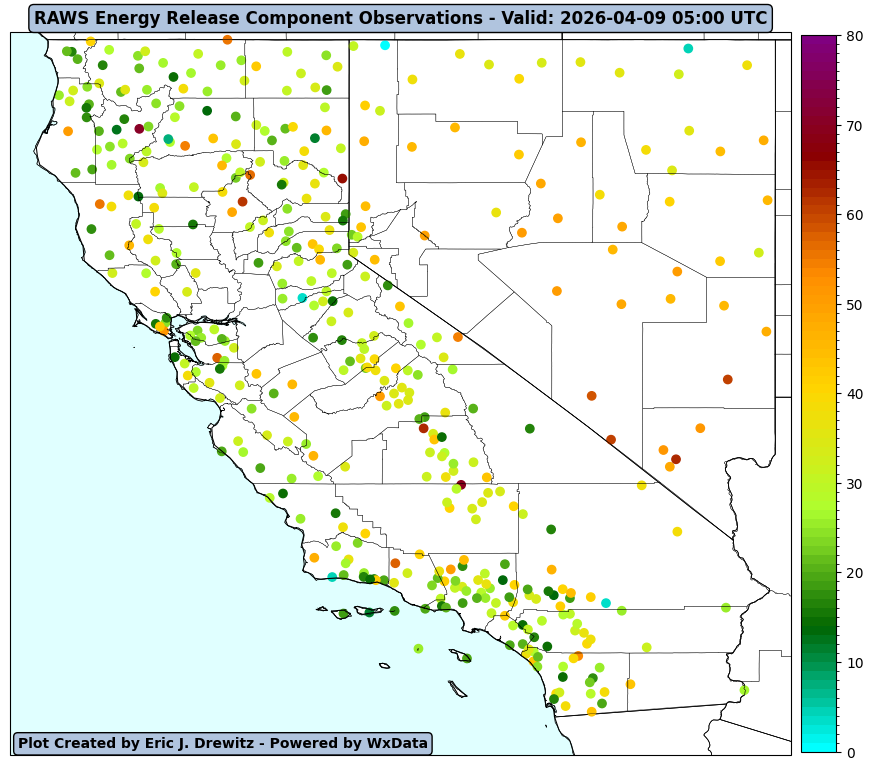

In [9]:
# Create our figure with a 12x12 figure size
fig = plt.figure(figsize=(12,12))

# Create our subplot axis using a cartopy PlateCarree projection
ax = fig.add_subplot(1,1,1, projection=ccrs.PlateCarree())

# Set our boundaries in a latlon format of [western_bound, eastern_bound, southern_bound, northern_bound] followed by our PlateCarree projection
# Bounds of CONUS -125, -65, 23.5, 50
ax.set_extent([-124.74, -113.82, 32, 42.11], ccrs.PlateCarree())

# Add our features to the map 
# Add our coastlines
ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.75, zorder=3)

# Add the oceans and color them light cyan
ax.add_feature(cfeature.OCEAN, color='lightcyan', zorder=1)
ax.add_feature(cfeature.STATES, edgecolor='black', linewidth=0.5, zorder=1)

# Adding our National Weather Service Public Forecast Zone Boundaries
# facecolor='none' -> No fill color
# edgecolor='black' -> Black edges (black demarcations on the map)
ax.add_geometries(shapes.geometries(), crs=ccrs.PlateCarree(), facecolor='none', edgecolor='black', linewidth=0.25, zorder=3)

# Let's create a custom colormap in this example. 
cmap = mcolors.LinearSegmentedColormap.from_list("energy release component", ["cyan", "darkgreen", "greenyellow", "gold", "darkorange", "darkred", "purple"])

# Normalize Our Colormap to go from 0 to 80 
norm = mcolors.BoundaryNorm(np.arange(0, 81, 1), ncolors=cmap.N, clip=True)

# Plot our data
cs = ax.scatter(ca['longitude'], ca['latitude'], c=ca['energyReleaseComponent'], cmap=cmap, norm=norm, transform=ccrs.PlateCarree())
ax.scatter(nv['longitude'], nv['latitude'], c=nv['energyReleaseComponent'], cmap=cmap, norm=norm, transform=ccrs.PlateCarree())

# Create our colorbar
cbar = fig.colorbar(cs, pad=0.01, shrink=0.775, ticks=[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100])

# Create a textbox
box = dict(boxstyle='round', facecolor='lightsteelblue')

# Create our title for our plot
ax.set_title(f"RAWS Energy Release Component Observations - Valid: {pd.to_datetime(ca['observationTime'].iloc[0]).strftime('%Y-%m-%d %H:00 UTC')}", fontweight='bold', bbox=box)

# Create a signature
ax.text(0.01, 0.01, f"Plot Created by Eric J. Drewitz - Powered by WxData", transform=ax.transAxes, fontweight='bold', bbox=box)
